In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

In [2]:
# ===== RUTAS =====
PROJECT_ROOT = Path.cwd().resolve().parents[3]

NOMBRE_SCALED = "CIC17__scaled__v1"
NOMBRE_PCA = "CIC17__pca__v1"

RUTA_SCALED = PROJECT_ROOT / "02_datasets" / "processed_analisis_estadistico" / NOMBRE_SCALED
RUTA_SALIDA = PROJECT_ROOT / "02_datasets" / "processed_analisis_estadistico" / NOMBRE_PCA

# ===== ARCHIVOS =====
TRAIN_FILE = f"{NOMBRE_SCALED}__train.csv"

PLOT_FILE = "pca_variance_plot.png"
REPORT_FILE = f"{NOMBRE_PCA}_report.json"

# ===== CONFIG =====
LABEL_COL = "LABEL"
VARIANCE_THRESHOLD = 0.95

In [3]:
print("Ruta entrada:", RUTA_SCALED)
print("Ruta salida:", RUTA_SALIDA)

Ruta entrada: /LUSTRE/home/inginf/u32902122/TFG/02_datasets/processed_analisis_estadistico/CIC17__scaled__v1
Ruta salida: /LUSTRE/home/inginf/u32902122/TFG/02_datasets/processed_analisis_estadistico/CIC17__pca__v1


In [4]:
train_path = RUTA_SCALED / TRAIN_FILE

if not train_path.exists():
    raise FileNotFoundError(train_path)

df = pd.read_csv(train_path)

print("Shape:", df.shape)

Shape: (2016638, 48)


In [5]:
X = df.drop(columns=[LABEL_COL])

print("Número de features:", X.shape[1])

Número de features: 47


In [6]:
pca = PCA()
pca.fit(X)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

In [7]:
k = np.argmax(cumulative_variance >= VARIANCE_THRESHOLD) + 1

print(f"k para {VARIANCE_THRESHOLD*100}% de varianza:", k)

k para 95.0% de varianza: 2


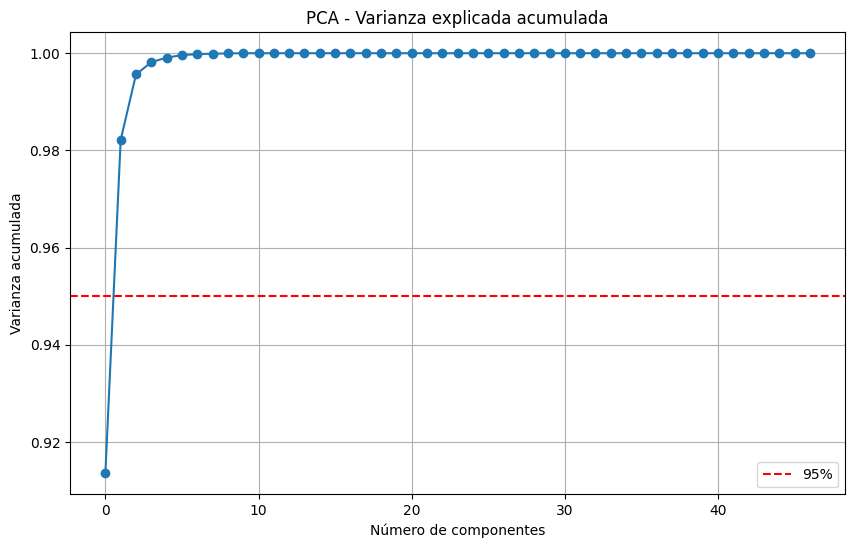

In [8]:
plt.figure(figsize=(10, 6))

plt.plot(cumulative_variance, marker='o')
plt.axhline(y=VARIANCE_THRESHOLD, color='r', linestyle='--', label='95%')

plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada")
plt.title("PCA - Varianza explicada acumulada")
plt.grid(True)
plt.legend()

plt.show()

In [9]:
RUTA_SALIDA.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10, 6))
plt.plot(cumulative_variance)
plt.axhline(y=VARIANCE_THRESHOLD, linestyle='--')

plt.savefig(RUTA_SALIDA / PLOT_FILE)
plt.close()

In [10]:
if k < 5:
    interpretacion = "Alta redundancia en las características"
elif k > 30:
    interpretacion = "Alta complejidad del espacio → justifica uso de LLM"
else:
    interpretacion = "Complejidad moderada del dataset"

print("Interpretación:", interpretacion)

Interpretación: Alta redundancia en las características


In [11]:
reporte = {
    "dataset": NOMBRE_SCALED,
    "num_features_original": int(X.shape[1]),
    "variance_threshold": VARIANCE_THRESHOLD,
    "k_components_95_variance": int(k),
    "explained_variance_first_10": explained_variance[:10].tolist(),
    "interpretation": interpretacion
}

with open(RUTA_SALIDA / REPORT_FILE, "w") as f:
    json.dump(reporte, f, indent=2)

print("Reporte guardado")

Reporte guardado


In [12]:
print("========== PCA RESULT ==========")
print("Features originales:", X.shape[1])
print("k (95% varianza):", k)
print("Interpretación:", interpretacion)
print("===============================")

========== PCA RESULT ==========
Features originales: 47
k (95% varianza): 2
Interpretación: Alta redundancia en las características


In [13]:
print("========== ANÁLISIS DE COMPONENTES PCA ==========\n")

import pandas as pd

# Crear DataFrame con las componentes
componentes = pd.DataFrame(
    pca.components_,
    columns=X.columns
)

# Número de componentes a analizar (puedes cambiarlo)
NUM_COMPONENTES = 5

for i in range(NUM_COMPONENTES):
    print(f"--- COMPONENTE PRINCIPAL {i+1} ---")
    
    # Ordenar por importancia (valor absoluto)
    top_features = componentes.iloc[i].abs().sort_values(ascending=False)
    
    # Mostrar top 10
    print("Top 10 variables más importantes:")
    display(top_features.head(10))
    
    print("\nValores con signo (para interpretación):")
    display(componentes.iloc[i][top_features.head(10).index])
    
    print("\n")

print("===============================================")

========== ANÁLISIS DE COMPONENTES PCA ==========

--- COMPONENTE PRINCIPAL 1 ---
Top 10 variables más importantes:


IDLE_STD                0.999771
ACTIVE_MAX              0.016425
ACTIVE_MEAN             0.010446
ACTIVE_STD              0.007175
ACTIVE_MIN              0.005143
BWD_IAT_MIN             0.000982
FWD_IAT_MIN             0.000223
FLOW_IAT_MIN            0.000051
MIN_SEG_SIZE_FORWARD    0.000050
FWD_HEADER_LENGTH       0.000028
Name: 0, dtype: float64


Valores con signo (para interpretación):


IDLE_STD                0.999771
ACTIVE_MAX              0.016425
ACTIVE_MEAN             0.010446
ACTIVE_STD              0.007175
ACTIVE_MIN              0.005143
BWD_IAT_MIN             0.000982
FWD_IAT_MIN            -0.000223
FLOW_IAT_MIN           -0.000051
MIN_SEG_SIZE_FORWARD   -0.000050
FWD_HEADER_LENGTH      -0.000028
Name: 0, dtype: float64



--- COMPONENTE PRINCIPAL 2 ---
Top 10 variables más importantes:


...

BWD_IAT_MIN     0.710824
FWD_IAT_MIN     0.702341
FLOW_IAT_MIN    0.030580
ACTIVE_STD      0.015194
ACTIVE_MEAN     0.012692
ACTIVE_MAX     -0.010031
ACTIVE_MIN     -0.004093
BWD_IAT_MEAN    0.001117
IDLE_STD       -0.000595
BWD_IAT_MAX     0.000260
Name: 3, dtype: float64



--- COMPONENTE PRINCIPAL 5 ---
Top 10 variables más importantes:


ACTIVE_STD              0.628456
ACTIVE_MEAN             0.602395
ACTIVE_MAX              0.465034
ACTIVE_MIN              0.154923
FWD_IAT_MIN             0.041672
BWD_IAT_MIN             0.009730
FWD_HEADER_LENGTH       0.005299
FLOW_IAT_MIN            0.004648
MIN_SEG_SIZE_FORWARD    0.004395
IDLE_STD                0.002387
Name: 4, dtype: float64


Valores con signo (para interpretación):


ACTIVE_STD              0.628456
ACTIVE_MEAN             0.602395
ACTIVE_MAX             -0.465034
ACTIVE_MIN             -0.154923
FWD_IAT_MIN            -0.041672
BWD_IAT_MIN             0.009730
FWD_HEADER_LENGTH      -0.005299
FLOW_IAT_MIN           -0.004648
MIN_SEG_SIZE_FORWARD   -0.004395
IDLE_STD               -0.002387
Name: 4, dtype: float64

In [14]:
print("========== DIAGNÓSTICO PCA ==========\n")

# 1. Shape
print("Shape de X:", X.shape)
print()

# 2. Columnas
print("Número de columnas:", len(X.columns))
print("Primeras 20 columnas:")
print(X.columns[:20])
print()

# 3. ¿Está LABEL dentro?
print("¿LABEL está en X?:", "LABEL" in X.columns)
print()

# 4. Tipos de datos
print("Tipos de datos:")
print(X.dtypes.value_counts())
print()

# 5. Columnas no numéricas (MUY IMPORTANTE)
non_numeric = X.select_dtypes(exclude=["int64", "float64"]).columns
print("Columnas NO numéricas:", list(non_numeric))
print()

# 6. Estadísticas básicas
print("Estadísticas básicas (primeras columnas):")
print(X.describe().iloc[:, :10])
print()

# 7. Desviación estándar (detección de columnas constantes)
stds = X.std()
print("Columnas con std ≈ 0:")
print(stds[stds < 1e-6].sort_values())
print()

# 8. Varianza explicada PCA
from sklearn.decomposition import PCA
import numpy as np

pca = PCA()
pca.fit(X)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

print("Primeras 10 varianzas explicadas:")
print(explained[:10])
print()

print("Varianza acumulada primeras 10:")
print(cumulative[:10])
print()

# 9. Resultado k
k = np.argmax(cumulative >= 0.95) + 1
print("k calculado:", k)

print("\n====================================")

========== DIAGNÓSTICO PCA ==========

Shape de X: (2016638, 47)

Número de columnas: 47
Primeras 20 columnas:
Index(['DESTINATION_PORT', 'FLOW_DURATION', 'TOTAL_FWD_PACKETS',
       'TOTAL_LENGTH_OF_FWD_PACKETS', 'FWD_PACKET_LENGTH_MAX',
       'FWD_PACKET_LENGTH_MIN', 'FWD_PACKET_LENGTH_MEAN',
       'BWD_PACKET_LENGTH_MAX', 'BWD_PACKET_LENGTH_MIN', 'FLOW_BYTES_S',
       'FLOW_PACKETS_S', 'FLOW_IAT_MEAN', 'FLOW_IAT_STD', 'FLOW_IAT_MAX',
       'FLOW_IAT_MIN', 'FWD_IAT_MEAN', 'FWD_IAT_STD', 'FWD_IAT_MIN',
       'BWD_IAT_TOTAL', 'BWD_IAT_MEAN'],
      dtype='str')

¿LABEL está en X?: False

Tipos de datos:
float64    47
Name: count, dtype: int64

Columnas NO numéricas: []

Estadísticas básicas (primeras columnas):


       DESTINATION_PORT  FLOW_DURATION  TOTAL_FWD_PACKETS  \
count      2.016638e+06   2.016638e+06       2.016638e+06   
mean       2.206378e+01   3.099702e+00       2.144194e+00   
std        4.873623e+01   6.600360e+00       2.059108e+02   
min       -2.051282e-01  -9.493426e-03      -2.500000e-01   
25%       -6.923077e-02  -9.452027e-03       0.000000e+00   
50%        0.000000e+00   0.000000e+00       0.000000e+00   
75%        9.307692e-01   9.905480e-01       1.000000e+00   
max        1.678333e+02   2.246947e+01       5.493925e+04   

       TOTAL_LENGTH_OF_FWD_PACKETS  FWD_PACKET_LENGTH_MAX  \
count                 2.016638e+06           2.016638e+06   
mean                  1.684888e+00           9.700323e-01   
std                   2.014267e+01           3.831778e+00   
min                  -2.062500e-01          -2.030457e-01   
25%                  -1.687500e-01          -1.725888e-01   
50%                   0.000000e+00           0.000000e+00   
75%                   8

Columnas con std ≈ 0:
Series([], dtype: float64)



Primeras 10 varianzas explicadas:
[9.13577602e-01 6.85977997e-02 1.34641213e-02 2.52039930e-03
 9.31946468e-04 5.19639660e-04 2.03112316e-04 8.00739852e-05
 7.40166609e-05 2.99286773e-05]

Varianza acumulada primeras 10:
[0.9135776  0.9821754  0.99563952 0.99815992 0.99909187 0.99961151
 0.99981462 0.99989469 0.99996871 0.99999864]

k calculado: 2



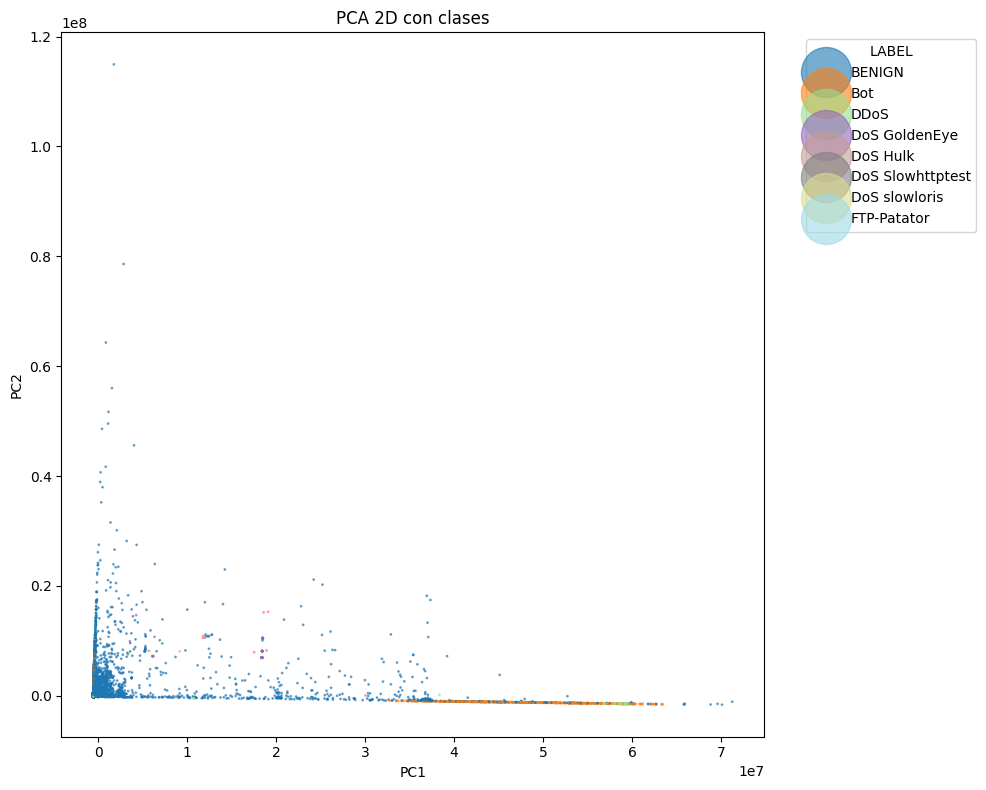

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Proyección PCA
X_pca = pca.transform(X)

# Convertir labels a códigos numéricos
labels_cat = pd.Categorical(df[LABEL_COL])
labels_num = labels_cat.codes

# Opcional: muestrear para no pintar 2 millones de puntos
sample_size = 100000
if len(df) > sample_size:
    idx = np.random.RandomState(42).choice(len(df), sample_size, replace=False)
else:
    idx = np.arange(len(df))

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    X_pca[idx, 0],
    X_pca[idx, 1],
    c=labels_num[idx],
    s=1,
    cmap="tab20",
    alpha=0.6
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA 2D con clases")

# Leyenda
handles, _ = scatter.legend_elements()
plt.legend(
    handles,
    labels_cat.categories,
    title=LABEL_COL,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    markerscale=6
)

plt.tight_layout()
plt.show()